# 2. Data Cleaning, EDA, and Baseline Modeling (QA/Defect Domain)

Cleans the combined NASA/PROMISE dataset (from notebook 1), runs EDA, and trains two
baseline defect-proneness classifiers (Logistic Regression, Random Forest).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
                              recall_score, f1_score, roc_auc_score, roc_curve)
from sklearn.impute import SimpleImputer

plt.style.use('seaborn-v0_8-whitegrid')

raw = pd.read_csv("../data/raw/nasa_promise_combined_raw.csv")
FEATURES = ['BRANCH_COUNT', 'CYCLOMATIC_COMPLEXITY', 'DESIGN_COMPLEXITY', 'ESSENTIAL_COMPLEXITY',
            'HALSTEAD_CONTENT', 'HALSTEAD_DIFFICULTY', 'HALSTEAD_EFFORT', 'HALSTEAD_ERROR_EST',
            'HALSTEAD_LENGTH', 'HALSTEAD_LEVEL', 'HALSTEAD_PROG_TIME', 'HALSTEAD_VOLUME',
            'LOC_BLANK', 'LOC_CODE_AND_COMMENT', 'LOC_COMMENTS', 'LOC_EXECUTABLE', 'LOC_TOTAL',
            'NUM_OPERANDS', 'NUM_OPERATORS', 'NUM_UNIQUE_OPERANDS', 'NUM_UNIQUE_OPERATORS']
print(f"Loaded {len(raw)} raw records")

Loaded 12655 raw records


## Data Cleaning

In [2]:
n_start = len(raw)
missing_pct = (raw[FEATURES].isna().sum() / n_start * 100).round(2)
total_missing_cells = raw[FEATURES].isna().sum().sum()
print(f"Total missing cells: {total_missing_cells} / {n_start*len(FEATURES)} ({total_missing_cells/(n_start*len(FEATURES))*100:.3f}%)")

dupes = raw.duplicated(subset=FEATURES+['project']).sum()
print(f"Duplicate rows (same project, identical metrics): {dupes} ({dupes/n_start*100:.2f}%)")

clean = raw.drop_duplicates(subset=FEATURES+['project']).copy()
n_after_dedup = len(clean)
print(f"Rows after removing duplicates: {n_after_dedup} (removed {n_start-n_after_dedup})")

imputer = SimpleImputer(strategy='median')
clean[FEATURES] = imputer.fit_transform(clean[FEATURES])
n_final = len(clean)
print(f"\nFinal cleaned N = {n_final}")

Total missing cells: 0 / 265755 (0.000%)
Duplicate rows (same project, identical metrics): 16 (0.13%)
Rows after removing duplicates: 12639 (removed 16)

Final cleaned N = 12639


In [3]:
outlier_summary = {}
for col in FEATURES:
    q1, q3 = clean[col].quantile(0.25), clean[col].quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    outlier_summary[col] = ((clean[col] < lower) | (clean[col] > upper)).sum()
outlier_series = pd.Series(outlier_summary).sort_values(ascending=False)
print("Outlier counts (IQR rule, top 5 features):")
print(outlier_series.head(5))
print("Note: Outliers retained (large/complex modules are legitimate high-risk cases).")

clean.to_csv("../data/cleaned/nasa_promise_combined_clean.csv", index=False)

Outlier counts (IQR rule, top 5 features):
LOC_CODE_AND_COMMENT    2874
HALSTEAD_EFFORT         1734
HALSTEAD_PROG_TIME      1734
LOC_COMMENTS            1499
ESSENTIAL_COMPLEXITY    1436
dtype: int64
Note: Outliers retained (large/complex modules are legitimate high-risk cases).


## Descriptive Statistics

In [4]:
key_metrics = ['LOC_TOTAL', 'CYCLOMATIC_COMPLEXITY', 'LOC_COMMENTS', 'HALSTEAD_VOLUME', 'BRANCH_COUNT']
print(clean[key_metrics].describe().round(2))

defect_by_project = clean.groupby('project')['Defective_bin'].agg(['count','mean'])
defect_by_project['mean'] = (defect_by_project['mean']*100).round(2)
defect_by_project.columns = ['n_modules', 'defect_rate_pct']
print("\nDefect rate by project (post-cleaning):")
print(defect_by_project)

       LOC_TOTAL  CYCLOMATIC_COMPLEXITY  LOC_COMMENTS  HALSTEAD_VOLUME  \
count   12639.00               12639.00      12639.00         12639.00   
mean       40.11                   6.41          4.35           835.59   
std        68.16                  12.22         11.23          2125.51   
min         0.00                   1.00          0.00             0.00   
25%        12.00                   2.00          0.00           151.27   
50%        23.00                   4.00          0.00           348.46   
75%        45.00                   7.00          4.00           806.90   
max      3442.00                 470.00        344.00         92835.55   

       BRANCH_COUNT  
count      12639.00  
mean          11.38  
std           21.24  
min            1.00  
25%            3.00  
50%            7.00  
75%           13.00  
max          826.00  

Defect rate by project (post-cleaning):
         n_modules  defect_rate_pct
project                            
CM1            327    

## Figure 1: Defect Rate by Project

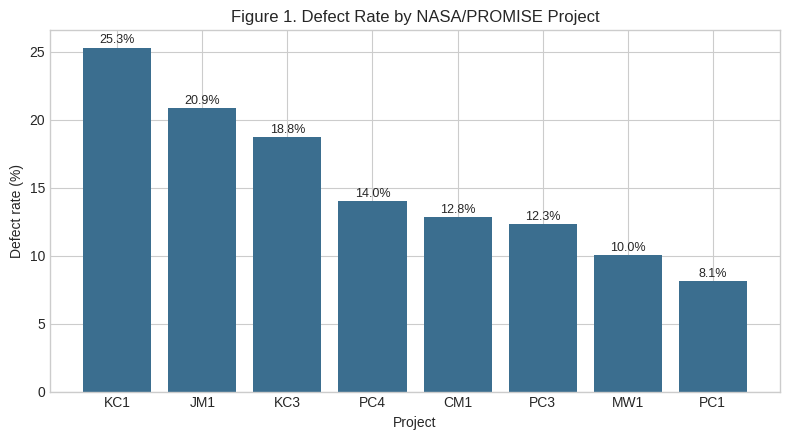

In [5]:
fig, ax = plt.subplots(figsize=(8,4.5))
d = defect_by_project.sort_values('defect_rate_pct', ascending=False)
ax.bar(d.index, d['defect_rate_pct'], color='#3B6E8F')
ax.set_ylabel('Defect rate (%)')
ax.set_xlabel('Project')
ax.set_title('Figure 1. Defect Rate by NASA/PROMISE Project')
for i, v in enumerate(d['defect_rate_pct']):
    ax.text(i, v+0.3, f"{v:.1f}%", ha='center', fontsize=9)
plt.tight_layout()
plt.savefig("../figures/fig1_defect_rate_by_project.png", dpi=150)
plt.show()

## Figure 2 & 3: Module Size and Complexity by Defect Status

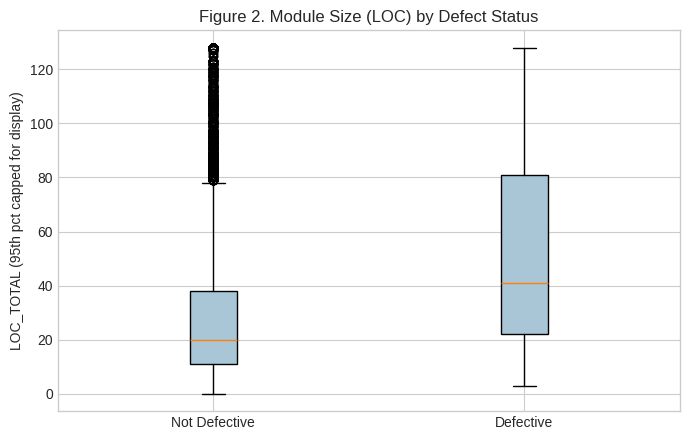

In [6]:
fig, ax = plt.subplots(figsize=(7,4.5))
data_box = [clean[clean.Defective_bin==0]['LOC_TOTAL'].clip(upper=clean['LOC_TOTAL'].quantile(0.95)),
            clean[clean.Defective_bin==1]['LOC_TOTAL'].clip(upper=clean['LOC_TOTAL'].quantile(0.95))]
ax.boxplot(data_box, tick_labels=['Not Defective','Defective'], patch_artist=True,
           boxprops=dict(facecolor='#A9C6D6'))
ax.set_ylabel('LOC_TOTAL (95th pct capped for display)')
ax.set_title('Figure 2. Module Size (LOC) by Defect Status')
plt.tight_layout()
plt.savefig("../figures/fig2_loc_by_defect.png", dpi=150)
plt.show()

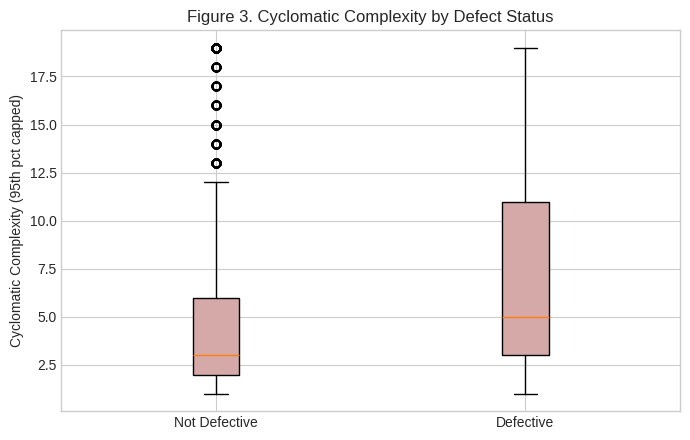

In [7]:
fig, ax = plt.subplots(figsize=(7,4.5))
data_box2 = [clean[clean.Defective_bin==0]['CYCLOMATIC_COMPLEXITY'].clip(upper=clean['CYCLOMATIC_COMPLEXITY'].quantile(0.95)),
             clean[clean.Defective_bin==1]['CYCLOMATIC_COMPLEXITY'].clip(upper=clean['CYCLOMATIC_COMPLEXITY'].quantile(0.95))]
ax.boxplot(data_box2, tick_labels=['Not Defective','Defective'], patch_artist=True,
           boxprops=dict(facecolor='#D6A9A9'))
ax.set_ylabel('Cyclomatic Complexity (95th pct capped)')
ax.set_title('Figure 3. Cyclomatic Complexity by Defect Status')
plt.tight_layout()
plt.savefig("../figures/fig3_complexity_by_defect.png", dpi=150)
plt.show()

## Modeling: Defect-Proneness Classification

In [8]:
X = clean[FEATURES].values
y = clean['Defective_bin'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")
print(f"Train defect rate: {y_train.mean()*100:.2f}%, Test defect rate: {y_test.mean()*100:.2f}%")

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

results = {}

Train size: 10111, Test size: 2528
Train defect rate: 18.75%, Test defect rate: 18.75%


In [9]:
logreg = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42)
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_lr = cross_val_score(logreg, X_train_s, y_train, cv=cv5, scoring='roc_auc')
logreg.fit(X_train_s, y_train)
pred_lr = logreg.predict(X_test_s)
proba_lr = logreg.predict_proba(X_test_s)[:,1]

results['LogisticRegression'] = {
    'cv_auc_mean': cv_scores_lr.mean(), 'cv_auc_std': cv_scores_lr.std(),
    'accuracy': accuracy_score(y_test, pred_lr), 'precision': precision_score(y_test, pred_lr),
    'recall': recall_score(y_test, pred_lr), 'f1': f1_score(y_test, pred_lr),
    'auc': roc_auc_score(y_test, proba_lr), 'cm': confusion_matrix(y_test, pred_lr)
}
print("Logistic Regression:")
for k,v in results['LogisticRegression'].items():
    print(f"  {k}: {v}")

Logistic Regression:
  cv_auc_mean: 0.7054798341983172
  cv_auc_std: 0.01399444495269267
  accuracy: 0.7171677215189873
  precision: 0.3453145057766367
  recall: 0.5675105485232067
  f1: 0.42936951316839583
  auc: 0.7188207428954105
  cm: [[1544  510]
 [ 205  269]]


In [10]:
rf = RandomForestClassifier(n_estimators=300, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1)
cv_scores_rf = cross_val_score(rf, X_train, y_train, cv=cv5, scoring='roc_auc')
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
proba_rf = rf.predict_proba(X_test)[:,1]

results['RandomForest'] = {
    'cv_auc_mean': cv_scores_rf.mean(), 'cv_auc_std': cv_scores_rf.std(),
    'accuracy': accuracy_score(y_test, pred_rf), 'precision': precision_score(y_test, pred_rf),
    'recall': recall_score(y_test, pred_rf), 'f1': f1_score(y_test, pred_rf),
    'auc': roc_auc_score(y_test, proba_rf), 'cm': confusion_matrix(y_test, pred_rf)
}
print("Random Forest:")
for k,v in results['RandomForest'].items():
    print(f"  {k}: {v}")

maj_pred = np.zeros_like(y_test)
print(f"\nMajority-class baseline accuracy: {accuracy_score(y_test, maj_pred):.3f}")

Random Forest:
  cv_auc_mean: 0.7153921984359547
  cv_auc_std: 0.013222507802569023
  accuracy: 0.7519778481012658
  precision: 0.37681159420289856
  recall: 0.4936708860759494
  f1: 0.4273972602739726
  auc: 0.7312807365683507
  cm: [[1667  387]
 [ 240  234]]

Majority-class baseline accuracy: 0.812


## Figure 4: ROC Curves

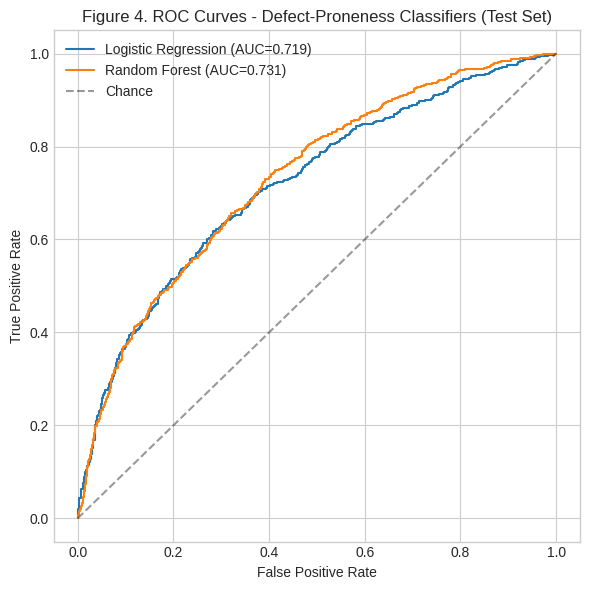

In [11]:
fig, ax = plt.subplots(figsize=(6,6))
for name, r, proba in [('Logistic Regression', results['LogisticRegression'], proba_lr),
                        ('Random Forest', results['RandomForest'], proba_rf)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC={r['auc']:.3f})")
ax.plot([0,1],[0,1],'k--', alpha=0.4, label='Chance')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Figure 4. ROC Curves - Defect-Proneness Classifiers (Test Set)')
ax.legend()
plt.tight_layout()
plt.savefig("../figures/fig4_roc_curves.png", dpi=150)
plt.show()

## Figure 5: Feature Importance

Top 8 features by Random Forest importance:
LOC_TOTAL              0.1296
LOC_EXECUTABLE         0.0775
HALSTEAD_CONTENT       0.0755
LOC_BLANK              0.0743
HALSTEAD_VOLUME        0.0630
NUM_OPERATORS          0.0579
NUM_UNIQUE_OPERANDS    0.0540
HALSTEAD_LENGTH        0.0529
dtype: float64


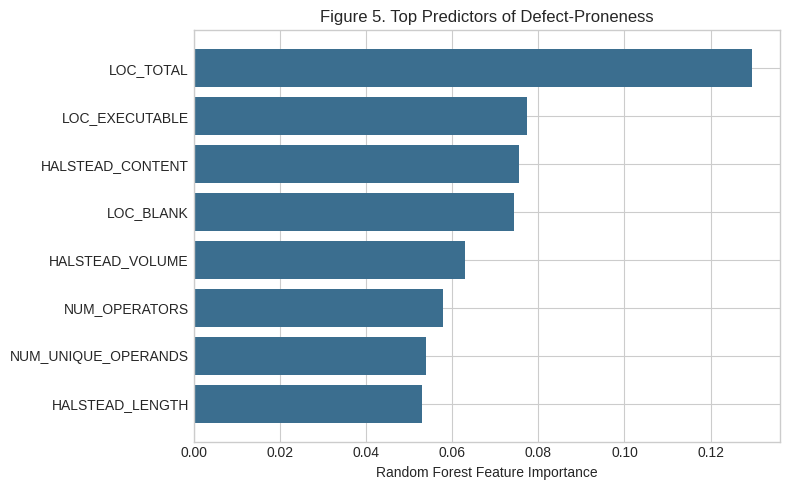

In [12]:
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False)
print("Top 8 features by Random Forest importance:")
print(importances.head(8).round(4))

top8 = importances.head(8).sort_values()
fig, ax = plt.subplots(figsize=(8,5))
ax.barh(top8.index, top8.values, color='#3B6E8F')
ax.set_xlabel('Random Forest Feature Importance')
ax.set_title('Figure 5. Top Predictors of Defect-Proneness')
plt.tight_layout()
plt.savefig("../figures/fig5_feature_importance.png", dpi=150)
plt.show()

In [13]:
import json
summary = {
    'n_raw': int(n_start), 'n_dupes_removed': int(n_start - n_after_dedup), 'n_final': int(n_final),
    'overall_defect_rate': float(clean['Defective_bin'].mean()),
    'train_size': int(len(X_train)), 'test_size': int(len(X_test)),
    'logreg_auc': float(results['LogisticRegression']['auc']),
    'rf_auc': float(results['RandomForest']['auc']),
    'majority_baseline_acc': float(accuracy_score(y_test, maj_pred)),
}
with open("../data/cleaned/nb2_summary.json", "w") as f:
    json.dump(summary, f, indent=2)
print("Saved nb2_summary.json")
print(summary)

Saved nb2_summary.json
{'n_raw': 12655, 'n_dupes_removed': 16, 'n_final': 12639, 'overall_defect_rate': 0.1875148350344173, 'train_size': 10111, 'test_size': 2528, 'logreg_auc': 0.7188207428954105, 'rf_auc': 0.7312807365683507, 'majority_baseline_acc': 0.8125}
